In [173]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
from shapely.geometry import Point

In [174]:
sns.set_style("darkgrid")

## Содержание датафрейма
##### Для расчёта EBITDA буду использовать формулу, используемую в российском сегменте рынка: 
##### Вр — СТ + НП + Пр + А, где
##### Вр - выручка от реализации продукции (код - 2110)
##### СТ - себестоимость продукции (код - 2120)
##### НП - налог на прибыль (код - 2410)
##### Пр - проценты по займам (код - 2330)
##### А - амортизация основных средств и нематериальных активов (код - 1150 и 1110 соответственно)

##### Помимо вышеперечисленного возьму показатель чистой прибыли для оценки рентабельности отрасли (код - 2400)


### Загрузка списка организаций

In [175]:
# Загружу таблицу с ИНН интересующих организаций
# Нужны малые и средние предприятия, занимающиеся строительством жилых и нежилых зданий
inns = pd.read_excel('https://github.com/garvelloken38/Construction_companies/blob/dev/inns.xlsx?raw=true', engine = 'openpyxl')

In [176]:
inns['Категория'].value_counts()

Категория
Малое предприятие      10183
Среднее предприятие      894
Name: count, dtype: int64

In [177]:
inns['Основной вид деятельности'].value_counts()

Основной вид деятельности
41.20 Строительство жилых и нежилых зданий    9413
41.2 Строительство жилых и нежилых зданий     1664
Name: count, dtype: int64

In [178]:
inns_list = inns['ИНН'].tolist()

### Создание датафрейма

In [48]:
session = requests.Session()

In [49]:
headers ={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36'}

In [54]:
# Сам скрипт 

df = pd.DataFrame(columns = range(45))
s=0

for inn in inns_list:
    
#   Находим org_id по ИНН
    
    predresponse = session.get(f'https://bo.nalog.gov.ru/advanced-search/organizations?\
                               allFieldsMatch=false&inn={inn}&page=0&size=20', headers = headers).json()
    try:
        org_id = predresponse['content'][0]['id']
    except:
        continue
    
#   Запрашиваем город в удобном формате
    
    try:
        if predresponse['content'][0]['region'].title() in ['Москва', 'Севастополь', 'Санкт-Петербург']:
            city = predresponse['content'][0]['region'].title()
            
        elif predresponse['content'][0]['city'] is None:
            city = predresponse['content'][0]['district'].title()    
            
        else:
            city = predresponse['content'][0]['city'].title()    

    except:
        city = 'Unknown'
        
    row_dict = {'INN': str(inn), 'org_id': str(org_id), 'city': city}

#   Запрашиваем финансовую отчётность    
    
    response = session.get(f'https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/',
                           headers = headers).json()

    for i in [0, 2, 4]:
        # чётные года
        try:
            row_dict[f'non_mat_assets_{2024 - i}'] = response[i]['typeCorrections'][0]['correction']['balance']['current1110']
        except:
            row_dict[f'non_mat_assets_{2024 - i}'] = float('Nan')
        try:
            row_dict[f'fixed_assets_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['balance']['current1150']
        except:
            row_dict[f'fixed_assets_{2024-i}'] = float('Nan')
        try:
            row_dict[f'rev_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2110']
        except:
            row_dict[f'rev_{2024-i}'] = float('Nan')
        try:
            row_dict[f'cost_price_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2120']
        except:
            row_dict[f'cost_price_{2024-i}'] = float('Nan')
        try:
            row_dict[f'tax_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2410']
        except:
            row_dict[f'tax_{2024-i}'] = float('Nan')
        try:
            row_dict[f'percent_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2330']
        except:
            row_dict[f'percent_{2024-i}'] = float('Nan')
            
        try:
            row_dict[f'profit_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2400']
        except:
            row_dict[f'profit_{2024-i}'] = float('Nan')
            

        # нечётные года
        try:
            row_dict[f'non_mat_assets_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['balance']['previous1110']
        except:
            row_dict[f'non_mat_assets_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'fixed_assets_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['balance']['previous1150']
        except:
            row_dict[f'fixed_assets_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'rev_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2110']
        except:
            row_dict[f'rev_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'cost_price_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2120']
        except:
            row_dict[f'cost_price_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'tax_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2410']
        except:
            row_dict[f'tax_{2024-(1+i)}'] = float('Nan')

        try:
            row_dict[f'percent_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2330']
        except:
            row_dict[f'percent_{2024-(1+i)}'] = float('Nan')

            
        try:
            row_dict[f'profit_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2400']
        except:
            row_dict[f'profit_{2024-(1+i)}'] = float('Nan')
    df.loc[s] = row_dict.values()
    s+=1

In [55]:
df = df.rename(columns = dict(zip(range(45), row_dict.keys())))

In [58]:
df.to_csv('./construction_orgs.csv', index = False)

### Исследование датафрейма

In [179]:
builders = pd.read_csv('https://github.com/garvelloken38/Construction_companies/blob/dev/construction_orgs.csv?raw=true')

In [180]:
builders = builders.dropna(how = 'all')

In [181]:
# Заменю пропущенные значения на нули 
# C одной стороны это исказит данные
# С другой - данные теряются, так как пропущенные значения есть практически в каждом ряду
builders[[col for col in builders.columns if col not in ['INN', 'org_id', 'city']]] = \
        builders[[col for col in builders.columns if col not in ['INN', 'org_id', 'city']]].fillna(0).astype('int')

In [182]:
builders[[x for x in builders.columns if x not in (['city', 'profit_2024', 'profit_2023', 'profit_2022', 'profit_2021', 'profit_2020', 'profit_2019'])]] = \
    builders[[x for x in builders.columns if x not in (['city', 'profit_2024', 'profit_2023', 'profit_2022', 'profit_2021', 'profit_2020', 'profit_2019'])]].apply(abs)

In [183]:
# Создам отдельный датафрейм с посчитанным показателем
ebitda = builders[['INN', 'org_id']]

In [184]:
for i in range(2019, 2025):
    ebitda[f'EBITDA_{i}'] = builders[f'rev_{i}'] - builders[f'cost_price_{i}'] + builders[f'tax_{i}'] \
    + builders[f'percent_{i}'] + builders[f'fixed_assets_{i}'] + builders[f'non_mat_assets_{i}']

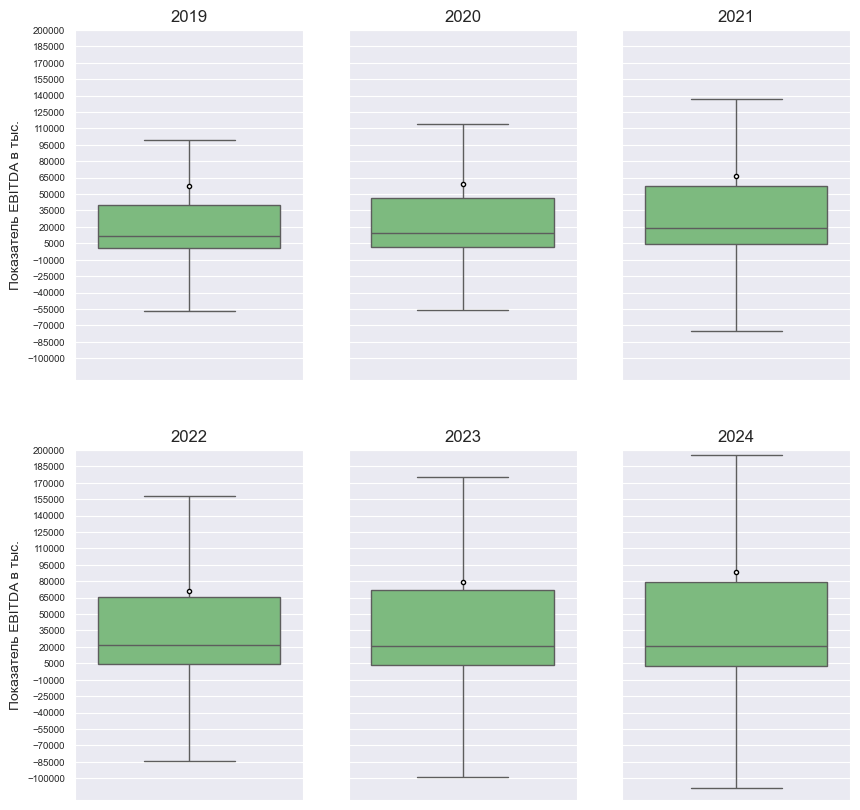

In [185]:
fig, axes = plt.subplots(2,3, sharex = False, sharey=True, figsize = (10,10))
axes = axes.flatten()
for i, year in enumerate(range(2019, 2025)):
    ax = axes[i]
    sns.boxplot(data = ebitda, ax = ax, y = f'EBITDA_{year}', showfliers = False, palette='Greens', \
                showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"3"})
    ax.set(ylabel="Показатель EBITDA в тыс.")
    ax.set_ylim(-120000, 200000)
    ax.set_yticks(np.linspace(-100000, 200000, 21))
    ax.set_title(year)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()


In [186]:
ebitda_avg_list = [ebitda['EBITDA_2019'].mean(), ebitda['EBITDA_2020'].mean(), ebitda['EBITDA_2021'].mean(),\
                   ebitda['EBITDA_2022'].mean(), ebitda['EBITDA_2023'].mean(), ebitda['EBITDA_2024'].mean()]

ebitda_median_list = [ebitda['EBITDA_2019'].median(), ebitda['EBITDA_2020'].median(), ebitda['EBITDA_2021'].median(),\
                   ebitda['EBITDA_2022'].median(), ebitda['EBITDA_2023'].median(), ebitda['EBITDA_2024'].mean()]


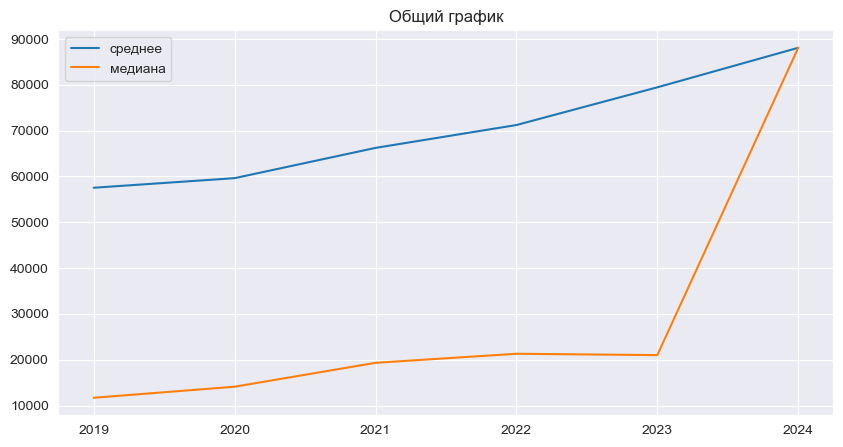

In [187]:
plt.figure(figsize = (10,5))
plt.title('Общий график')
sns.lineplot(x = range(2019, 2025), y = ebitda_avg_list, label = 'среднее')
sns.lineplot(x = range(2019, 2025), y = ebitda_median_list, label = 'медиана')
plt.show()

#### К сожалению данных ранее 2019 года нет, однако на общем графике видно падение в 2019 г. - на этот период пришлось начало эпидемии ковида (конец 2019г. - Январь 2020 г.).
#### Вследствие чего, я предположу, упал спрос на жильё, а изоляция привела к задержкам сдачи проектов (работники на карантине, доставка материалов задерживается)
#### После чего следует медленное восстановление вплоть до резкого подъёма в 2022, согласно среднему, и в 2023, согласно медиане.

#### Огромный размах между медианным и средним значениями (вплоть до 2024 г.) может говорить о том, что более крупные компании восстанавливались быстрее (и скорее всего изначально потеряли меньше), благодаря, возможно, субсидиям.

#### Строительство характеризуется долгосрочными проектами, поэтому финансовые результаты в 2022–2023 годах могут отражать отдачу от работ, начатых ещё до пандемии. Постепенное восстановление после 2019 года и последующий рост подтверждают, что отрасль успешно завершает эти проекты.

#### Исходя из ebitda можно сделать вывод, что строительная отрасль (жилых и нежилых зданий) продемонстрировала способность адаптироваться к чёрным лебедям

### Датафрейм с чистой прибылью и его анализ

In [188]:
profit = builders[['INN', 'org_id', 'profit_2024', 'profit_2023', 'profit_2022', \
                   'profit_2021', 'profit_2020', 'profit_2019']]

In [189]:
# Инфляцию никто не отменял, поэтому рубль 2019 г. != рублю 2024 г. 
# Для дисконтирования возьму данные с сайта ЦБ: https://cbr.ru/hd_base/infl/
# (Значения на момент Декабря каждого года)/100 + 1, чтобы сразу умножать, в 2019г - 1, так как базовый
inflation = [1, 1.049, 1.0839, 1.1194, 1.0742, 1.0952]

deflator = inflation
for i in range (5):
    deflator[i+1] = deflator[i]*deflator[i+1]

In [190]:
for year in range(2019, 2025):
    profit[f'fixed_profit_{year}'] = round(profit[f'profit_{year}'] / deflator[year - 2019], 2)

In [191]:
profit_median_list = [profit['profit_2019'].median(), profit['profit_2020'].median(), profit['profit_2021'].median(), profit['profit_2022'].median(), \
               profit['profit_2023'].median(), profit['profit_2024'].median()]

fixed_profit_median_list = [profit['fixed_profit_2019'].median(), profit['fixed_profit_2020'].median(), profit['fixed_profit_2021'].median(), \
                            profit['fixed_profit_2022'].median(), profit['fixed_profit_2023'].median(), profit['fixed_profit_2024'].median()]

In [192]:
nom_real = pd.DataFrame({'Год': list(range(2019, 2025))*2, 'Категория': ['Номинальная'] * 6 + ['Реальная']*6, \
                         'Значение': profit_median_list + fixed_profit_median_list})

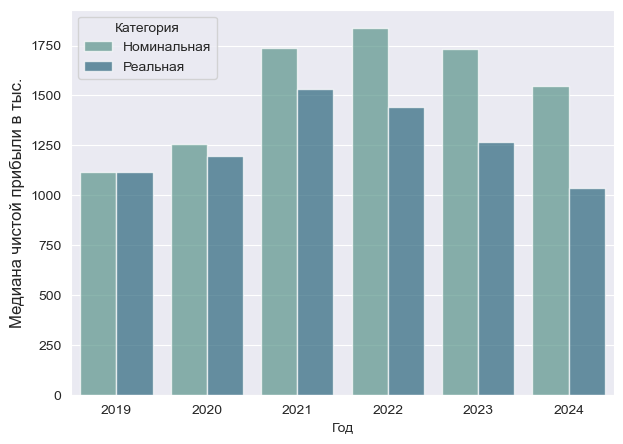

In [193]:
fig, ax = plt.subplots(figsize = (7,5))
sns.barplot(ax = ax, data = nom_real, x = 'Год', y = 'Значение', hue = 'Категория', palette = 'crest', alpha = 0.7)
ax.set_ylabel('Медиана чистой прибыли в тыс.', fontdict = {'size': 12})
plt.show()

In [194]:
for year in range(2020, 2025):
    profit[f'growth_{year}'] = round(((profit[f'profit_{year}'] - profit[f'profit_{year-1}']) \
                                      /  profit[f'profit_{year-1}']), 2) * 100

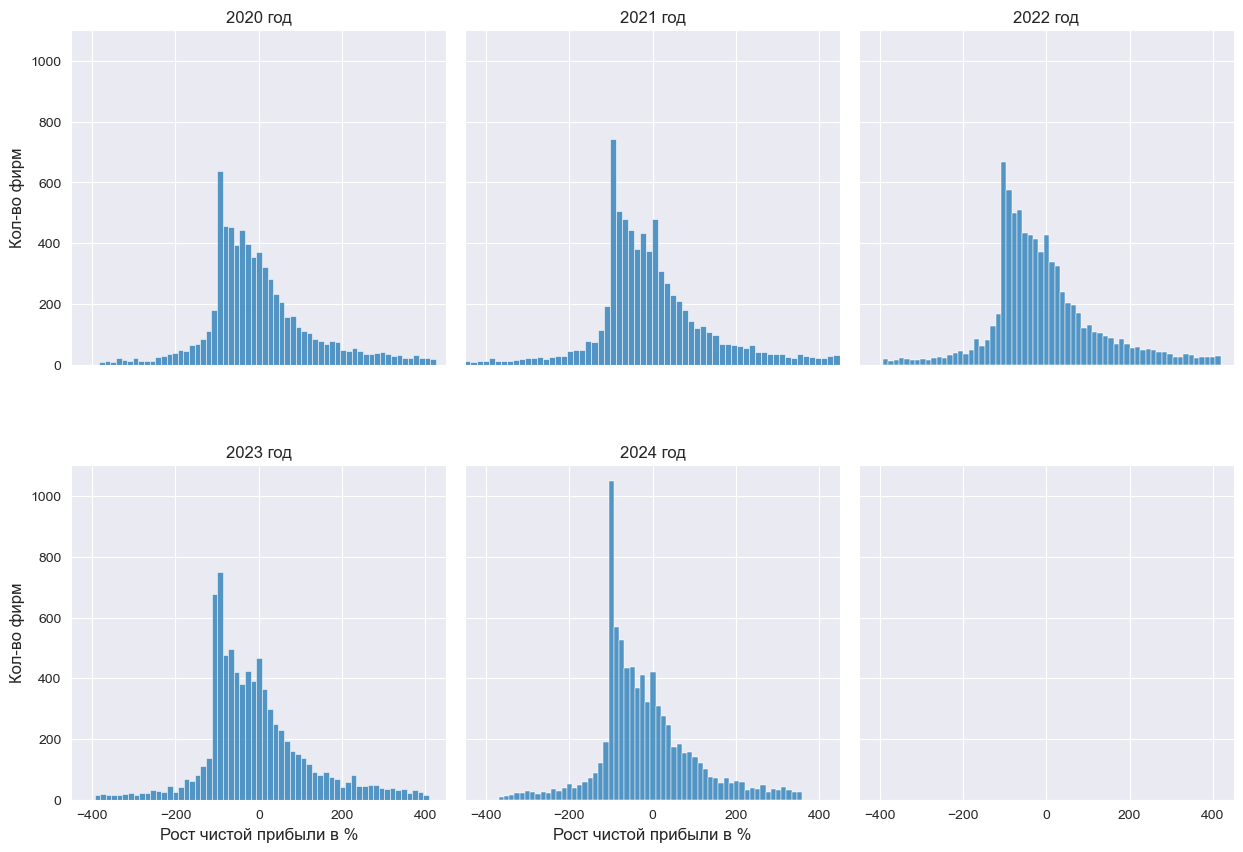

In [195]:
fig, axes = plt.subplots(2,3, sharex = True, sharey=True, figsize = (15,10))
axes = axes.flatten()

for year in range(2020, 2025):
    x = profit[f'growth_{year}']

    # В данных много выбросов - так как некоторые поля делились на ноль
    q1 = x.quantile(0.25)
    q2 = x.quantile(0.75)
    max = q2 + 1.5*(q2 - q1)
    min = q1 - 1.5*(q2 - q1)
    
    x = profit[(x <= max) & (x >= min)][f'growth_{year}']
    ax = axes[year - 2020]
    
    sns.histplot(ax = ax, x = x)
    
    ax.set_xlabel('Рост чистой прибыли в %', fontdict = {'size': 12})
    ax.set_ylabel('Кол-во фирм', fontdict = {'size': 12})
    ax.set_title(f'{year} год')

    ax.set_xlim(-450, 450)
    
plt.subplots_adjust(wspace=0.05, hspace=0.3)  
plt.show()

### Города топ 500 фирм по выручке

In [198]:
top_500 = builders.sort_values(by = 'rev_2024', ascending = False)['city'][:500].tolist()

In [199]:
city_coordinates = session.get('https://raw.githubusercontent.com/pensnarik/russian-cities/refs/heads/master/russian-cities.json', \
                               headers = headers).json()

In [200]:
city_dict = {}
for i in range(len(city_coordinates)):
    city_dict[f'{city_coordinates[i]['name']}'] = city_coordinates[i]['coords']

In [201]:
# датафрейм с координатами городов из списка
df_city = pd.DataFrame(columns = ['City', 'lat', 'lon'])

for i, city in enumerate(top_500):
    try:
        df_city.loc[i] = [city, city_dict[city]['lat'], city_dict[city]['lon']]
    except:
        continue

In [202]:
df_city['lat'] = pd.to_numeric(df_city['lat'])
df_city['lon'] = pd.to_numeric(df_city['lon'])
df_city['geometry'] = df_city.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
cities_gdf = gpd.GeoDataFrame(df_city, geometry='geometry', crs='EPSG:4326')

In [203]:
# Отмечу четыре крупных города
big_cities = {'name': ['Москва', 'Санкт-Петербург', 'Казань', 'Краснодар'], 
          'geometry': [Point(city_dict['Москва']["lon"], city_dict['Москва']["lat"]),
                       Point(city_dict['Санкт-Петербург']["lon"], city_dict['Санкт-Петербург']["lat"]),
                       Point(city_dict['Казань']["lon"], city_dict['Казань']["lat"]),
                       Point(city_dict['Краснодар']["lon"], city_dict['Краснодар']["lat"])]}

big_cities_gdf = gpd.GeoDataFrame(Big_cities, crs="EPSG:4326")

big_cities_gdf = big_cities_gdf.to_crs('ESRI:102027')

In [204]:
# Карта 2021 г. Взята с: https://habr.com/ru/articles/752406/
russia = gpd.read_file('https://github.com/hairymax/offline_russia_plotly/raw/main/data/russia_regions.geojson')
russia = russia.set_crs('EPSG:4326', allow_override=True)

In [205]:
cities_gdf = cities_gdf.to_crs('ESRI:102027')
russia = russia.to_crs('ESRI:102027')

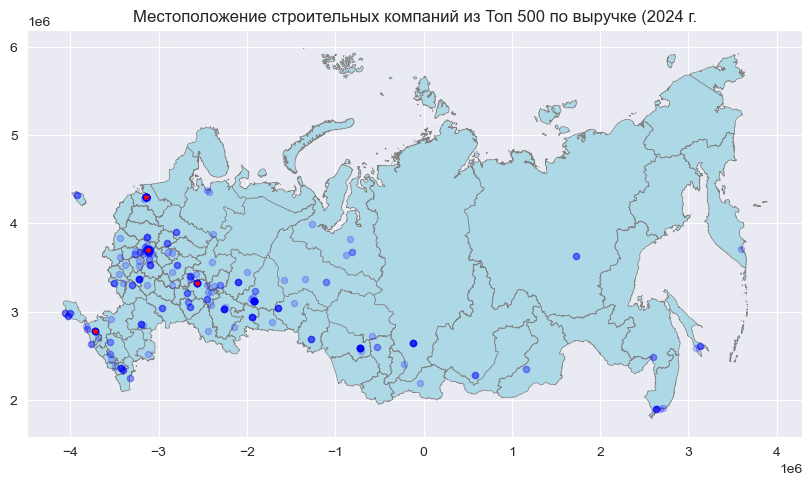

In [206]:
fig, ax = plt.subplots(figsize=(10, 8))

russia.plot(ax=ax, color='lightblue', edgecolor='gray', linewidth=0.5)
cities_gdf.plot(ax=ax, color='blue',markersize=20, marker='o', alpha=0.2)
big_cities_gdf.plot(ax=ax, color='red',markersize=10, marker='*')

plt.title("Местоположение строительных компаний из Топ 500 по выручке (2024 г.")
plt.show()

# Выводы
### Из гистограмм видно, что прибыль распределена вокруг нуля - как и предполагалось из различия медианы и среднего - доходы в отрасли распределены неравномерно. Это также можно наблюдать на ящиках с усами, что с кажным годом всё больше расширяются - это может означать, что богатые фирмы стаовятся всё богаче, а бедные терпят всё большие убытки. 

### На карте видно, что крупные (для малых и средних) фирмы тяготеют к богатым и густонаселённым регионам Европейской части России - там наблюдается высокий спрос на жильё и коммерческую недвижимость.

### Возможные колебания в 2020 (пандемия) и 2022 (санкции) могли временно снизить рентабельность, но восстановление в 2023–2024 годах говорит об адаптации отрасли к новым условиям.

### Средняя рентабельность, вероятно, умеренная, но зависит от масштаба компании